# 01 - Data Exploration: STimage-1K4M Breast Cancer Dataset

**Project:** SpaHisto-Net  
**Dataset:** STimage-1K4M (Breast subset)  
**Goal:** Explore the structure, quality, and characteristics of the 205 breast samples before preprocessing and splitting.

This notebook covers:
- Dataset summary (total samples, annotated vs non-annotated)
- File structure verification
- Basic statistics (spots per sample, gene counts)
- Visualization of example samples (H&E + spatial coordinates)
- Analysis of the 24 annotated samples
- Identification of the 6 normal (non-cancer) samples

In [1]:
from google.colab import drive
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from collections import Counter

drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# ====================== PROJECT PATHS ======================
PROJECT_ROOT = Path("/content/drive/My Drive/MSC Project/SpaHisto-Net")
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw" / "STimage-1k4M"
# ===========================================================

print("Project root:", PROJECT_ROOT)
print("Raw data folder:", RAW_DATA_DIR)
print("Folder exists:", RAW_DATA_DIR.exists())

Project root: /content/drive/My Drive/MSC Project/SpaHisto-Net
Raw data folder: /content/drive/My Drive/MSC Project/SpaHisto-Net/data/raw/STimage-1k4M
Folder exists: True


In [11]:
# Dataset Summary

import pandas as pd

# Path to your metadata file (update if different)
META_PATH = RAW_DATA_DIR / "meta_all_gene.csv"
# ===========================================================

sample_folders = sorted([f for f in RAW_DATA_DIR.iterdir() if f.is_dir()])
total_samples = len(sample_folders)

print("=" * 65)
print("DATASET SUMMARY: STimage-1K4M Breast Subset")
print("=" * 65)
print(f"Total breast samples: {total_samples}")

# Load metadata to identify normal samples
meta = pd.read_csv(META_PATH)
meta_breast = meta[meta['tissue'] == 'breast'].copy()

# Identify normal (non-cancer) samples
normal_slides = meta_breast[meta_breast['involve_cancer'] == False]['slide'].tolist()
print(f"\nNormal (non-cancer) samples in metadata: {len(normal_slides)}")

# Check which normal samples we actually have in our folder
normal_samples_in_data = [s for s in normal_slides if (RAW_DATA_DIR / s).exists()]
print(f"Normal samples present in our data folder: {len(normal_samples_in_data)}")

# Annotated samples (already counted earlier)
annotated_samples = [s.name for s in sample_folders if any("_anno.csv" in f.name.lower() for f in s.iterdir() if f.is_file())]

print(f"\nSamples with annotation.csv : {len(annotated_samples)} / {total_samples}")
print(f"Normal (non-cancer) samples : {len(normal_samples_in_data)} / {total_samples}")

print("\nNormal sample IDs:")
print(normal_samples_in_data)

print("\nAnnotated sample IDs (first 10):")
print(annotated_samples[:10])

DATASET SUMMARY: STimage-1K4M Breast Subset
Total breast samples: 205

Normal (non-cancer) samples in metadata: 6
Normal samples present in our data folder: 6

Samples with annotation.csv : 24 / 205
Normal (non-cancer) samples : 6 / 205

Normal sample IDs:
['Human_Breast_10X_02132023_Visium', 'Human_Breast_10X_06092021_Visium', 'Human_Breast_10X_06232020_Visium_Block_A_Section_1', 'Human_Breast_10X_06232020_Visium_Block_A_Section_2', 'Human_Breast_10X_07012022_Visium', 'Human_Breast_10X_10272020_Visium_WholeTranscriptome']

Annotated sample IDs (first 10):
['GSE213688_GSM6592049', 'GSE213688_GSM6592050', 'GSE213688_GSM6592051', 'GSE213688_GSM6592052', 'GSE213688_GSM6592053', 'GSE213688_GSM6592054', 'GSE213688_GSM6592055', 'GSE213688_GSM6592056', 'GSE213688_GSM6592057', 'GSE213688_GSM6592058']


In [ ]:
#Explore sample structure

# Pick first sample as example
example_sample = sample_folders[0]
print(f"Example sample: {example_sample.name}\n")

for f in sorted(example_sample.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:25} ({size_kb:8.1f} KB)")

Example sample: GSE203612_GSM6177599

  .cache                    (     4.0 KB)
  GSE203612_GSM6177599.png  ( 10707.5 KB)
  GSE203612_GSM6177599_coord.csv (   147.1 KB)
  GSE203612_GSM6177599_count.csv (312911.6 KB)


In [8]:
import pandas as pd
from pathlib import Path

# Ensure example_sample is defined for this cell's execution
# Assuming 'sample_folders' is available from a previous cell (e.g., EZ-E_bhJuDAC)
sample_folders = sorted([f for f in RAW_DATA_DIR.iterdir() if f.is_dir()])
example_sample = sample_folders[0]

sample_name = example_sample.name
sample_path = RAW_DATA_DIR / sample_name
coords = pd.read_csv(sample_path / f"{sample_name}_coord.csv")
print(coords.head())
print("\nColumn names:", coords.columns.tolist())

                                Unnamed: 0   yaxis   xaxis         r
0  GSE203612_GSM6177599_AAACACCAATAACTGC-1  1446.0  1348.0  7.083075
1  GSE203612_GSM6177599_AAACAGTGTTCCTGGG-1  1184.0  1613.0  7.083075
2  GSE203612_GSM6177599_AAACATTTCCCGGATT-1   596.0  1384.0  7.083075
3  GSE203612_GSM6177599_AAACCGGGTAGGTACC-1  1349.0  1025.0  7.083075
4  GSE203612_GSM6177599_AAACCGTTCGTCCAGG-1  1196.0  1215.0  7.083075

Column names: ['Unnamed: 0', 'yaxis', 'xaxis', 'r']


In [ ]:
for i, sample_path_obj in enumerate(sample_folders):
    if i >= 5: # Limit to first 5 samples for demonstration
        break

    sample_id = sample_path_obj.name
    print(f"\nVisualizing sample: {sample_id}")

    # Ensure the save directory exists
    save_image_dir.mkdir(parents=True, exist_ok=True)

    try:
        visualize_sample(sample_id, save_path=save_image_dir / f"{sample_id}_aligned_spots.png")
    except Exception as e:
        print(f"Error visualizing {sample_id}: {e}")

Image saved to: /content/drive/My Drive/MSC Project/SpaHisto-Net/visualizations/data_exploration/GSE203612_GSM6177601_aligned_spots.png


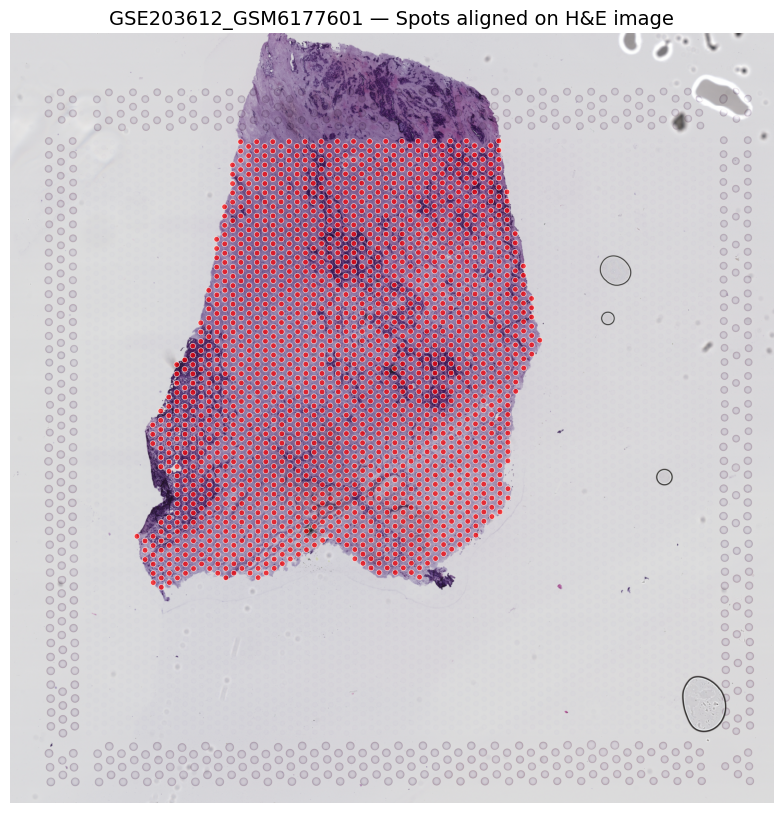

Image size: (1984, 2000)
Number of spots: 1863
Spot radius range: 7.828963481847201 – 7.828963481847201


In [16]:
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def visualize_sample(sample_id, save_path=None):
    base = Path("/content/drive/My Drive/MSC Project/SpaHisto-Net/data/raw/STimage-1k4M") / sample_id

    # Access the first .png file, as each sample folder is expected to contain only one image.
    img_path = list(base.glob("*.png"))[0] # glob pattern to find files ending with .png
    img = Image.open(img_path)

    coords = pd.read_csv(base / f"{sample_id}_coord.csv") # coord file name

    plt.figure(figsize=(12, 10))
    plt.imshow(img)

    plt.scatter(coords['xaxis'], coords['yaxis'],
                c='red', s=coords['r']*2, alpha=0.7, edgecolors='white', linewidths=0.5)

    plt.title(f"{sample_id} — Spots aligned on H&E image", fontsize=14)
    plt.axis('off')

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Image saved to: {save_path}")

    plt.show()

    print(f"Image size: {img.size}")
    print(f"Number of spots: {len(coords)}")
    print(f"Spot radius range: {coords['r'].min()} – {coords['r'].max()}")

# Test with one sample using a valid sample name from sample_folders
# Also demonstrating how to save the image
save_image_dir = Path("/content/drive/My Drive/MSC Project/SpaHisto-Net/visualizations/data_exploration")
sample_to_visualize = sample_folders[1].name
visualize_sample(sample_to_visualize, save_path=save_image_dir / f"{sample_to_visualize}_aligned_spots.png")


Visualizing selected sample (index 70): GSE242311_GSM7757970
Image saved to: /content/drive/My Drive/MSC Project/SpaHisto-Net/visualizations/data_exploration/GSE242311_GSM7757970_aligned_spots.png


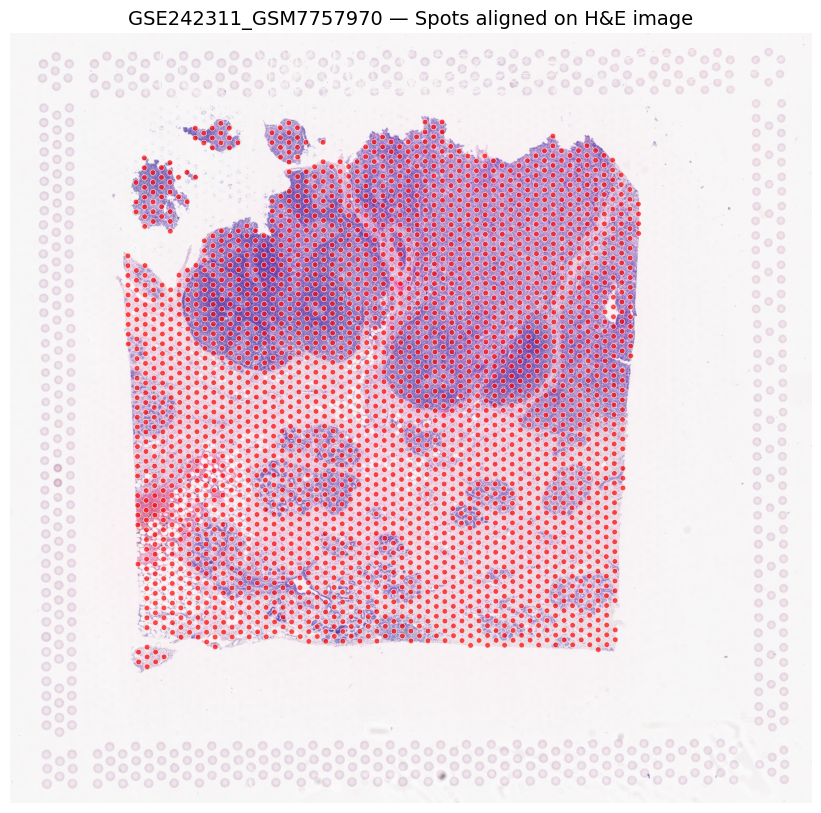

Image size: (2000, 1921)
Number of spots: 2830
Spot radius range: 7.934097090487121 – 7.934097090487121


In [86]:
# @title Select a sample by index and visualize it
sample_index = 70 # @param {type:"integer", min:0, max:204}

if 0 <= sample_index < len(sample_folders):
    selected_sample_path_obj = sample_folders[sample_index]
    sample_id = selected_sample_path_obj.name
    print(f"\nVisualizing selected sample (index {sample_index}): {sample_id}")

    # Ensure the save directory exists
    save_image_dir.mkdir(parents=True, exist_ok=True)

    try:
        visualize_sample(sample_id, save_path=save_image_dir / f"{sample_id}_aligned_spots.png")
    except Exception as e:
        print(f"Error visualizing {sample_id}: {e}")
else:
    print(f"Error: Invalid sample index {sample_index}. Please choose an index between 0 and {len(sample_folders) - 1}.")

In [15]:
sample_id_check = sample_folders[1].name
base_check = Path("/content/drive/My Drive/MSC Project/SpaHisto-Net/data/raw/STimage-1k4M") / sample_id_check
png_files_found = list(base_check.glob("*.png"))

print(f"PNG files found in {base_check}:")
if png_files_found:
    for i, f in enumerate(png_files_found):
        print(f"  [{i}]: {f.name}")
else:
    print("  No PNG files found.")

print(f"\nNumber of PNG files found: {len(png_files_found)}")

PNG files found in /content/drive/My Drive/MSC Project/SpaHisto-Net/data/raw/STimage-1k4M/GSE203612_GSM6177601:
  [0]: GSE203612_GSM6177601.png

Number of PNG files found: 1


In [ ]:
# Annotation analysis

print("Analyzing the 24 annotated samples...\n")

all_labels = []

for sample_name in annotated_samples[:5]:   # Check first 5 for now
    annot_path = RAW_DATA_DIR / sample_name / f"{sample_name}_anno.csv"
    if annot_path.exists():
        df = pd.read_csv(annot_path)
        print(f"{sample_name}: {df.shape[0]} annotated spots")
        # Check for 'Annotations' column
        if 'Annotations' in df.columns:
            print(df['Annotations'].value_counts())
            all_labels.extend(df['Annotations'].tolist())
        else:
            print("Warning: 'Annotations' column not found in this sample's annotation file.")
        print("-" * 50)

print("\nMost common labels across annotated samples:")
print(Counter(all_labels).most_common(10))

Analyzing the 24 annotated samples...

GSE213688_GSM6592049: 1848 annotated spots
Annotations
Tumor stroma with inflammation    853
Tumor cells                       312
Adipose tissue                    259
Tumor stroma fibrous              206
Artifacts                          42
Name: count, dtype: int64
--------------------------------------------------
GSE213688_GSM6592050: 2417 annotated spots
Annotations
Tumor Cells     1083
Tumor Stroma     717
Artifacts        245
Name: count, dtype: int64
--------------------------------------------------
GSE213688_GSM6592051: 1564 annotated spots
Annotations
Fibrosis          321
Artifacts         216
Tumor cells       177
Adipose tissue    159
Tumor Stroma       59
Name: count, dtype: int64
--------------------------------------------------
GSE213688_GSM6592052: 2104 annotated spots
Annotations
Tumour Cells        639
High TILs Stroma    529
Fibrosis            516
Name: count, dtype: int64
-------------------------------------------------

In [ ]:
# Save summary for later use

summary_df = pd.DataFrame({
    "sample": [s.name for s in sample_folders],
    "has_annotation": [any("_anno.csv" in f.name.lower() for f in s.iterdir() if f.is_file()) for s in sample_folders]
})

summary_path = PROJECT_ROOT / "data" / "processed" / "stimage_breast_summary.csv"
summary_path.parent.mkdir(parents=True, exist_ok=True)
summary_df.to_csv(summary_path, index=False)

print(f"Summary saved to: {summary_path}")
print(f"\nAnnotated samples: {summary_df['has_annotation'].sum()}")

Summary saved to: /content/drive/My Drive/MSC Project/SpaHisto-Net1/data/processed/stimage_breast_summary.csv

Annotated samples: 24


## Summary

- We have **205 breast samples** from STimage-1K4M.
- All samples have complete core files (`image`, `coords.csv`, `counts.csv`).
- **24 samples** have pathologist annotations (high-quality ground truth).
- We will use these 24 annotated samples as our **supervised subset**.
- The remaining samples will be used under a weakly supervised setting.